# EfficientNetB4 + Enhanced Multi-Scale FSDA + Adaptive CB Focal + TTA — Garlic Disease Classification

**Novel Architecture Contribution:** Enhanced Multi-Scale FSDA with frequency-band attention, gated frequency-spatial fusion, scale-aware local/semantic fusion, Adaptive CB Focal Loss, and test-time augmentation.

| Item | Value |
|---|---|
| **Architecture** | EfficientNetB4 + Enhanced Multi-Scale FSDA |
| **Input size** | 380 × 380 × 3 |
| **FSDA — Freq Branch** | FFT2D -> low/mid/high band descriptors -> channel attention |
| **FSDA — Spatial Branch** | Avg+Max pool -> Conv2D(7x7) -> spatial attention |
| **Fusion** | Element-wise addition of two attended feature maps |
| **Head** | GAP → BN → Dense(256,relu) → Dropout → softmax |
| **Optimizer** | AdamW + CosineDecay (lr=3e-5 -> 1e-6) |
| **Loss** | Adaptive Class-Balanced Focal Loss v2 (2-phase recall-adaptive) |
| **Regularisation** | Dropout 0.55 + L2 1e-4 + Class-weight balancing |
| **Strategy** | 3-seed independent runs for statistical robustness |

---

## Why FSDA?

Garlic diseases manifest as **texture anomalies** (spots, lesions, discolouration) that correspond to **specific spatial frequency patterns**:
- **High-frequency components** → sharp disease boundaries, spot edges
- **Mid-frequency components** → lesion texture, surface roughness  
- **Low-frequency components** → overall colour/illumination changes

Standard CNN+GAP treats all spatial positions and all channels equally. FSDA provides two complementary re-weightings:
1. **Frequency Channel Attention** — *which channels carry disease-relevant frequency information?*
2. **Spatial Attention** — *where in the image are the disease lesions located?*

In [1]:
# ========== 1. IMPORTS ========== #
import os
import csv
import time
import random
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm_lib
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization,
    Conv2D, Activation, Input,
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, Callback
from tensorflow.keras.regularizers import l2

from sklearn.utils import class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    top_k_accuracy_score, roc_curve, auc, roc_auc_score,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# ========== 2. GPU CONFIG ========== #
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", len(gpus))
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

# ========== 3. MIXED PRECISION ========== #
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Compute dtype :", tf.keras.mixed_precision.global_policy().compute_dtype)
print("Variable dtype:", tf.keras.mixed_precision.global_policy().variable_dtype)

2026-05-23 06:36:31.850134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779518192.242131      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779518192.349882      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779518193.323424      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779518193.323477      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779518193.323480      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: 2
GPU memory growth enabled.
Compute dtype : float16
Variable dtype: float32


In [2]:
# ========== 4. EXPERIMENT CONFIGURATION ========== #

# -- STRATEGY ---------------------------------------------------------------
STRATEGY_KEY    = "efficientnetb4_efsda_adaptivecb_tta"
STRATEGY_LABEL  = "EfficientNetB4 + Enhanced MS-FSDA + Adaptive CB Focal + TTA"
UNFREEZE_BLOCKS = [4, 5, 6, 7]
USE_AUG         = True
LR              = 6e-5
MIN_LR          = 1e-6
WEIGHT_DECAY    = 1e-5
# --------------------------------------------------------------------------

# -- ENHANCED FSDA HYPERPARAMETERS -----------------------------------------
# Frequency-band attention learns low/mid/high frequency channel weights.
# Gated branch fusion learns image-dependent weights for frequency vs spatial cues.
# Multi-scale fusion combines local texture maps and final semantic maps.
FSDA_REDUCTION    = 16
FSDA_SPATIAL_KS   = 7
FUSION_DIM        = 256
# --------------------------------------------------------------------------

# -- ADAPTIVE CB FOCAL LOSS ------------------------------------------------
FOCAL_GAMMA       = 1.5
CB_BETA           = 0.995
ADAPTIVE_TAU      = 0.08
PHASE1_EPOCHS     = 10
MIN_RECALL_GAP    = 0.06
ADAPTIVE_FACTOR_MIN = 0.85
ADAPTIVE_FACTOR_MAX = 1.25
ADAPTIVE_RECALL_EMA = 0.70
LABEL_SMOOTHING   = 0.02
# --------------------------------------------------------------------------

# -- TEST-TIME AUGMENTATION ------------------------------------------------
TTA_STEPS         = 5    # 1 = disabled; 5 gives original + 4 stochastic views
# --------------------------------------------------------------------------

# --- Paths ---
DATA_DIR        = "/kaggle/input/datasets/giaphuc/update-clean-dataset/split_70_15_15"
BASE_RESULT_DIR = f"/kaggle/working/report_EfficientNetB4/{STRATEGY_KEY}"
os.makedirs(BASE_RESULT_DIR, exist_ok=True)

# --- Model ---
INPUT_SHAPE = (380, 380, 3)
BATCH_SIZE  = 32
EPOCHS      = 30

# --- Shared hyperparameters ---
DROPOUT_RATE    = 0.35
PATIENCE        = 12
BEST_MODEL_MONITOR = 'val_auc_ovr'
BEST_MODEL_MODE    = 'max'

# --- Multi-run settings ---
N_RUNS       = 3
RANDOM_SEEDS = [42, 123, 456]

# --- Performance knobs ---
AUTOTUNE = tf.data.AUTOTUNE
tf.config.optimizer.set_jit(True)

# --- Result storage ---
all_runs_results = []

print(f"Strategy   : {STRATEGY_LABEL}  (key={STRATEGY_KEY})")
print(f"Unfreeze   : {UNFREEZE_BLOCKS}  |  Augmentation: {USE_AUG}  |  LR: {LR} -> {MIN_LR}")
print(f"Dataset    : {DATA_DIR}")
print(f"Output dir : {BASE_RESULT_DIR}")
print(f"Input shape: {INPUT_SHAPE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"N_RUNS     : {N_RUNS}  |  Seeds: {RANDOM_SEEDS[:N_RUNS]}")
print(f"Enhanced FSDA: reduction={FSDA_REDUCTION}  spatial_ks={FSDA_SPATIAL_KS}  fusion_dim={FUSION_DIM}")
print(f"Loss       : Adaptive CB Focal v2 (gamma={FOCAL_GAMMA}, beta={CB_BETA}, tau={ADAPTIVE_TAU})")
print(f"Checkpoint : {BEST_MODEL_MONITOR} ({BEST_MODEL_MODE})")
print(f"TTA        : {TTA_STEPS} stochastic views")
print(f"XLA JIT    : ON")


Strategy   : EfficientNetB4 + Enhanced MS-FSDA + Adaptive CB Focal + TTA  (key=efficientnetb4_efsda_adaptivecb_tta)
Unfreeze   : [4, 5, 6, 7]  |  Augmentation: True  |  LR: 2e-05 -> 1e-06
Dataset    : /kaggle/input/datasets/giaphuc/update-clean-dataset/split_70_15_15
Output dir : /kaggle/working/report_EfficientNetB4/efficientnetb4_efsda_adaptivecb_tta
Input shape: (380, 380, 3)
Batch size : 32
N_RUNS     : 3  |  Seeds: [42, 123, 456]
Enhanced FSDA: reduction=16  spatial_ks=7  fusion_dim=256
Loss       : Adaptive CB Focal v2 (gamma=1.5, beta=0.999, tau=0.07)
Checkpoint : val_accuracy (max)
TTA        : 5 stochastic views
XLA JIT    : ON


In [3]:
# ========== 5. HELPER FUNCTIONS + ADAPTIVE CB LOSS + TTA ========== #

efficientnet_preprocess = tf.keras.applications.efficientnet.preprocess_input

_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.06),
    tf.keras.layers.RandomZoom(0.12),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
    tf.keras.layers.RandomBrightness(factor=0.20, value_range=(0, 255)),
    tf.keras.layers.RandomContrast(factor=0.15, value_range=(0, 255)),
], name='augmentation')

_tta_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
], name='tta_augmentation')


def apply_freeze_strategy(base, unfreeze_blocks):
    """Selectively unfreeze EfficientNetB4 blocks (BN always frozen)."""
    base.trainable = False
    if unfreeze_blocks == "all":
        for layer in base.layers:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True
    elif isinstance(unfreeze_blocks, list) and len(unfreeze_blocks) > 0:
        for layer in base.layers:
            for block_num in unfreeze_blocks:
                if layer.name.startswith(f"block{block_num}"):
                    if not isinstance(layer, tf.keras.layers.BatchNormalization):
                        layer.trainable = True
                    break
    trainable = sum(1 for l in base.layers if l.trainable)
    total     = len(base.layers)
    print(f"  [{STRATEGY_LABEL}] {trainable}/{total} base layers trainable (BN always frozen)")


def _collect_samples(split_dir, class_to_idx):
    """Walk split_dir -> (abs_paths, int_labels, rel_filenames), sorted."""
    paths, labels, filenames = [], [], []
    for cn, ci in sorted(class_to_idx.items()):
        d = os.path.join(split_dir, cn)
        for fname in sorted(os.listdir(d)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
                paths.append(os.path.join(d, fname))
                labels.append(ci)
                filenames.append(f"{cn}/{fname}")
    return paths, labels, filenames


def create_tf_datasets(data_dir, input_shape, batch_size, seed=None, use_aug=True):
    """Build GPU-optimised tf.data pipelines (one-hot labels for training)."""
    class_names  = sorted([
        d for d in os.listdir(os.path.join(data_dir, 'train'))
        if os.path.isdir(os.path.join(data_dir, 'train', d))
    ])
    class_to_idx = {cn: i for i, cn in enumerate(class_names)}
    num_classes  = len(class_names)
    h, w         = input_shape[:2]

    def load_image(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [h, w])
        img = tf.cast(img, tf.float32)
        return img, label

    def preprocess(img, label):
        img = efficientnet_preprocess(img)
        label = tf.one_hot(label, depth=num_classes)
        return img, label

    def augment(img, lbl):
        return _augmentation(img, training=True), lbl

    def _make_split(split, training=False, apply_augmentation=False):
        sdir               = os.path.join(data_dir, split)
        paths, labels, fns = _collect_samples(sdir, class_to_idx)
        n  = len(paths)
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        if training:
            ds = ds.shuffle(n, seed=seed, reshuffle_each_iteration=True)
        ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
        if apply_augmentation:
            ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(batch_size, drop_remainder=training)
        ds = ds.prefetch(AUTOTUNE)
        return ds, n, fns, labels

    train_ds, n_train, _,           train_lbl  = _make_split('train', training=True,  apply_augmentation=use_aug)
    val_ds,   n_val,   _,           _          = _make_split('val',   training=False, apply_augmentation=False)
    test_ds,  n_test,  test_fnames, test_lbl   = _make_split('test',  training=False, apply_augmentation=False)

    cw      = class_weight.compute_class_weight(
        'balanced', classes=np.unique(train_lbl), y=train_lbl)
    cw_dict = dict(enumerate(cw))
    samples_per_class = [train_lbl.count(i) for i in range(num_classes)]

    meta = SimpleNamespace(
        class_names       = class_names,
        class_to_idx      = class_to_idx,
        num_classes       = num_classes,
        test_filenames    = test_fnames,
        test_classes      = np.array(test_lbl),
        n_train           = n_train,
        n_val             = n_val,
        n_test            = n_test,
        class_weight_dict = cw_dict,
        samples_per_class = samples_per_class,
    )
    aug_info = "ON" if use_aug else "OFF"
    print(f"  Augmentation: {aug_info}  |  train={n_train}  val={n_val}  test={n_test}")
    print(f"  Samples/class: {dict(zip(class_names, samples_per_class))}")
    return train_ds, val_ds, test_ds, meta


def compute_multiclass_auc(y_true, pred_probs, class_names):
    """Return one-vs-rest AUC metrics for multiclass classification."""
    num_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    per_class_auc = {}
    roc_curves = {}

    for class_idx, class_name in enumerate(class_names):
        if len(np.unique(y_true_bin[:, class_idx])) < 2:
            per_class_auc[class_name] = np.nan
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, class_idx], pred_probs[:, class_idx])
        per_class_auc[class_name] = float(auc(fpr, tpr))
        roc_curves[class_name] = (fpr, tpr)

    auc_values = np.array(list(per_class_auc.values()), dtype=np.float32)
    class_support = np.bincount(y_true, minlength=num_classes).astype(np.float32)
    valid_auc = ~np.isnan(auc_values)
    auc_macro = float(np.nanmean(auc_values)) if np.any(valid_auc) else np.nan
    auc_weighted = (float(np.sum(auc_values[valid_auc] * class_support[valid_auc]) /
                          np.sum(class_support[valid_auc])) if np.any(valid_auc) else np.nan)
    auc_micro = (float(roc_auc_score(y_true_bin.ravel(), pred_probs.ravel()))
                 if len(np.unique(y_true_bin.ravel())) > 1 else np.nan)

    return {
        'auc_macro': auc_macro,
        'auc_weighted': auc_weighted,
        'auc_micro': auc_micro,
        'per_class_auc': per_class_auc,
        'roc_curves': roc_curves,
    }


def tta_predict(model, dataset, tta_steps=5):
    """Average predictions over original + stochastic augmented test views."""
    all_probs = []
    for batch_x, _ in dataset:
        batch_probs = [model(batch_x, training=False)]
        for _ in range(max(tta_steps - 1, 0)):
            aug_x = _tta_augmentation(batch_x, training=True)
            batch_probs.append(model(aug_x, training=False))
        probs = tf.reduce_mean(tf.stack(batch_probs, axis=0), axis=0)
        all_probs.append(probs.numpy())
    return np.concatenate(all_probs, axis=0)


class AdaptiveClassBalancedFocalLossV2(tf.keras.losses.Loss):
    """2-phase Adaptive Class-Balanced Focal Loss.

    Phase 1 uses static effective-number class weights. Phase 2 multiplies
    those weights by recall-driven adaptive factors updated by callback.
    """
    def __init__(self, samples_per_class, num_classes, gamma=1.5, beta=0.999,
                 label_smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.beta = beta
        self.num_classes = num_classes
        self.label_smoothing = label_smoothing
        self._samples_per_class = list(samples_per_class)

        n = np.array(samples_per_class, dtype=np.float32)
        eff_num = 1.0 - np.power(beta, n)
        weights = (1.0 - beta) / np.maximum(eff_num, 1e-8)
        weights = weights / weights.sum() * num_classes
        self.static_weights = tf.constant(weights, dtype=tf.float32)
        self.adaptive_factor = tf.Variable(
            tf.ones([num_classes], dtype=tf.float32),
            trainable=False, name='adaptive_cb_factor_v2')
        self.adaptation_active = tf.Variable(
            False, trainable=False, name='adaptation_active')

        print(f"  Static CB weights: {dict(zip(range(num_classes), weights.round(4)))}")

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_hard = y_true

        if self.label_smoothing > 0:
            y_true = y_true * (1.0 - self.label_smoothing) + \
                     self.label_smoothing / tf.cast(tf.shape(y_true)[-1], tf.float32)

        combined_weights = tf.cond(
            self.adaptation_active,
            lambda: self.static_weights * self.adaptive_factor,
            lambda: self.static_weights,
        )
        combined_weights = combined_weights / tf.reduce_mean(combined_weights)

        sample_w = tf.reduce_sum(y_true_hard * combined_weights, axis=-1)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal = tf.pow(1.0 - pt, self.gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        return tf.reduce_mean(sample_w * focal * ce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'samples_per_class': self._samples_per_class,
            'num_classes': self.num_classes,
            'gamma': self.gamma,
            'beta': self.beta,
            'label_smoothing': self.label_smoothing,
        })
        return cfg


class TwoPhaseAdaptiveCallback(Callback):
    """Update adaptive CB factors from validation recall after warmup."""
    def __init__(self, loss_fn, val_ds, num_classes, class_names,
                 phase1_epochs=12, tau=0.07, min_recall_gap=0.08,
                 factor_min=0.75, factor_max=1.35, recall_ema=0.60,
                 **kwargs):
        super().__init__(**kwargs)
        self.loss_fn = loss_fn
        self.val_ds = val_ds
        self.num_classes = num_classes
        self.class_names = class_names
        self.phase1_epochs = phase1_epochs
        self.tau = tau
        self.min_recall_gap = min_recall_gap
        self.factor_min = factor_min
        self.factor_max = factor_max
        self.recall_ema = recall_ema
        self.smoothed_recall = None
        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred_probs = self.model.predict(self.val_ds, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in self.val_ds])

        per_class_recall = np.zeros(self.num_classes, dtype=np.float32)
        for c in range(self.num_classes):
            mask = y_true == c
            per_class_recall[c] = (y_pred[mask] == c).mean() if mask.sum() > 0 else 1.0

        if self.smoothed_recall is None:
            self.smoothed_recall = per_class_recall.copy()
        else:
            self.smoothed_recall = (
                self.recall_ema * self.smoothed_recall +
                (1.0 - self.recall_ema) * per_class_recall
            )

        current_factor = self.loss_fn.adaptive_factor.numpy()
        phase = "Phase 1 (static)" if (epoch + 1) <= self.phase1_epochs else "Phase 2 (adaptive)"

        if (epoch + 1) == self.phase1_epochs + 1:
            self.loss_fn.adaptation_active.assign(True)
            print(f"\n  >>> PHASE 2 ACTIVATED at epoch {epoch+1} <<<")

        if (epoch + 1) > self.phase1_epochs:
            recall_for_update = self.smoothed_recall
            recall_gap = recall_for_update.max() - recall_for_update.min()
            if recall_gap > self.min_recall_gap:
                epsilon = 0.15
                target = (1.0 - recall_for_update) + epsilon
                new_factor = (1.0 - self.tau) * current_factor + self.tau * target
                new_factor = new_factor / new_factor.mean()
                new_factor = np.clip(new_factor, self.factor_min, self.factor_max)
                new_factor = new_factor / new_factor.mean()
                self.loss_fn.adaptive_factor.assign(new_factor.astype(np.float32))
                current_factor = new_factor
                status = f"adapted (gap={recall_gap:.3f})"
            else:
                status = f"skipped (gap={recall_gap:.3f}<{self.min_recall_gap})"
        else:
            status = "monitoring only"

        self.history.append({
            'epoch': epoch + 1,
            'phase': phase,
            'per_class_recall': per_class_recall.copy(),
            'smoothed_recall': self.smoothed_recall.copy(),
            'adaptive_factor': current_factor.copy(),
        })
        print(f"  [AdaptiveCB-v2] Epoch {epoch+1} | {phase} | {status}")
        print(f"    Recall : {dict(zip(self.class_names, [f'{r:.3f}' for r in per_class_recall]))}")
        print(f"    EMA    : {dict(zip(self.class_names, [f'{r:.3f}' for r in self.smoothed_recall]))}")
        print(f"    Factors: {dict(zip(self.class_names, [f'{f:.3f}' for f in current_factor]))}")


print("Helper functions, Adaptive CB Focal v2, and TTA defined.")


Helper functions, Adaptive CB Focal v2, and TTA defined.


I0000 00:00:1779518233.101846      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779518233.108066      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# ========== 6. ENHANCED MULTI-SCALE FSDA ARCHITECTURE ========== #
# Contributions applied here:
#   1. Frequency-band channel attention: low/mid/high FFT bands instead of one global spectrum.
#   2. Gated FSDA branch fusion: content-dependent frequency vs spatial weighting.
#   3. Multi-scale FSDA: local EfficientNet block5 features + final semantic features.
#   4. Scale-aware fusion: content-dependent local vs semantic weighting.
#   5. AdamW + CosineDecay and Adaptive CB Focal Loss v2.


class FrequencyBandChannelAttention(tf.keras.layers.Layer):
    """Channel attention from low/mid/high FFT magnitude bands."""
    def __init__(self, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        C = input_shape[-1]
        self._C = C
        r = max(C // self.reduction, 8)
        self.fc1 = Dense(r, use_bias=False, dtype='float32', name=f'{self.name}_fc1')
        self.fc2 = Dense(C, use_bias=False, dtype='float32', name=f'{self.name}_fc2')
        self.fc1.build((None, 3 * C))
        self.fc2.build((None, r))
        super().build(input_shape)

    def _radial_masks(self, h, w, dtype):
        yy = tf.cast(tf.range(h), dtype) - (tf.cast(h, dtype) - 1.0) / 2.0
        xx = tf.cast(tf.range(w), dtype) - (tf.cast(w, dtype) - 1.0) / 2.0
        yy = yy / (tf.cast(h, dtype) / 2.0 + 1e-6)
        xx = xx / (tf.cast(w, dtype) / 2.0 + 1e-6)
        gy, gx = tf.meshgrid(yy, xx, indexing='ij')
        radius = tf.sqrt(tf.square(gx) + tf.square(gy))
        low = tf.cast(radius <= 0.33, dtype)
        mid = tf.cast((radius > 0.33) & (radius <= 0.66), dtype)
        high = tf.cast(radius > 0.66, dtype)
        return low, mid, high

    def call(self, x, training=False):
        x_f32 = tf.cast(x, tf.float32)
        x_t = tf.transpose(x_f32, [0, 3, 1, 2])
        x_fft = tf.signal.fft2d(tf.complex(x_t, tf.zeros_like(x_t)))
        mag = tf.math.log1p(tf.abs(x_fft))
        mag = tf.signal.fftshift(mag, axes=(2, 3))

        h = tf.shape(mag)[2]
        w = tf.shape(mag)[3]
        masks = self._radial_masks(h, w, tf.float32)

        descs = []
        for mask in masks:
            denom = tf.reduce_sum(mask) + 1e-6
            desc = tf.reduce_sum(mag * mask[None, None, :, :], axis=[2, 3]) / denom
            descs.append(desc)
        freq_desc = tf.concat(descs, axis=-1)

        attn = tf.nn.relu(self.fc1(freq_desc))
        attn = tf.nn.sigmoid(self.fc2(attn))
        attn = tf.reshape(attn, [tf.shape(x_f32)[0], 1, 1, tf.shape(x_f32)[3]])
        out = x_f32 * attn
        return tf.cast(out, x.dtype)

    def get_config(self):
        cfg = super().get_config()
        cfg['reduction'] = self.reduction
        return cfg


# Backward-friendly alias for older saved custom_objects references.
FrequencyChannelAttention = FrequencyBandChannelAttention


class FSDABlock(tf.keras.layers.Layer):
    """Gated Frequency-Spatial Dual Attention block."""
    def __init__(self, reduction=16, spatial_kernel=7, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction
        self.spatial_kernel = spatial_kernel

    def build(self, input_shape):
        C = input_shape[-1]
        self.freq_attn = FrequencyBandChannelAttention(
            self.reduction, name=f'{self.name}_freq_band_attn')
        self.sp_conv = Conv2D(
            1, self.spatial_kernel, padding='same', use_bias=False,
            kernel_initializer='glorot_uniform', dtype='float32',
            name=f'{self.name}_sp_conv')
        self.gate = Dense(2, activation='softmax', dtype='float32',
                          name=f'{self.name}_branch_gate')
        self.bn = BatchNormalization(dtype='float32', name=f'{self.name}_bn')

        self.freq_attn.build(input_shape)
        self.sp_conv.build(tuple(input_shape[:-1]) + (2,))
        self.gate.build((None, 2 * C))
        self.bn.build(input_shape)
        super().build(input_shape)

    def call(self, x, training=False):
        input_dtype = x.dtype
        x_f32 = tf.cast(x, tf.float32)

        freq_out = tf.cast(self.freq_attn(x, training=training), tf.float32)

        avg_pool = tf.reduce_mean(x_f32, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x_f32, axis=-1, keepdims=True)
        sp_attn = tf.nn.sigmoid(self.sp_conv(tf.concat([avg_pool, max_pool], axis=-1)))
        spatial_out = x_f32 * sp_attn

        freq_desc = tf.reduce_mean(freq_out, axis=[1, 2])
        spatial_desc = tf.reduce_mean(spatial_out, axis=[1, 2])
        branch_weights = self.gate(tf.concat([freq_desc, spatial_desc], axis=-1))
        w_freq = branch_weights[:, 0:1, None, None]
        w_spatial = branch_weights[:, 1:2, None, None]

        fused = w_freq * freq_out + w_spatial * spatial_out
        fused = self.bn(fused + x_f32, training=training)
        return tf.cast(fused, input_dtype), sp_attn, branch_weights

    def compute_output_spec(self, x, training=False):
        import keras
        sp_shape = tuple(x.shape[:-1]) + (1,)
        gate_shape = (x.shape[0], 2)
        return (
            keras.KerasTensor(x.shape, dtype=x.dtype),
            keras.KerasTensor(sp_shape, dtype='float32'),
            keras.KerasTensor(gate_shape, dtype='float32'),
        )

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'reduction': self.reduction, 'spatial_kernel': self.spatial_kernel})
        return cfg


class ScaleAwareFusion(tf.keras.layers.Layer):
    """Fuse local and semantic vectors with content-dependent scale weights."""
    def __init__(self, feat_dim=256, **kwargs):
        super().__init__(**kwargs)
        self.feat_dim = feat_dim
        self.proj_local = Dense(self.feat_dim, use_bias=False, dtype='float32',
                                name=f'{self.name}_proj_local')
        self.proj_semantic = Dense(self.feat_dim, use_bias=False, dtype='float32',
                                   name=f'{self.name}_proj_semantic')
        self.gate = Dense(2, activation='softmax', dtype='float32',
                          name=f'{self.name}_scale_gate')
        self.bn = BatchNormalization(dtype='float32', name=f'{self.name}_bn')

    def build(self, input_shape):
        local_shape = tf.TensorShape(input_shape[0]).as_list()
        semantic_shape = tf.TensorShape(input_shape[1]).as_list()
        batch_dim = local_shape[0]
        self._input_shape_for_build = [local_shape, semantic_shape]

        if not self.proj_local.built:
            self.proj_local.build(tuple(local_shape))
        if not self.proj_semantic.built:
            self.proj_semantic.build(tuple(semantic_shape))
        if not self.gate.built:
            self.gate.build((batch_dim, self.feat_dim * 2))
        if not self.bn.built:
            self.bn.build((batch_dim, self.feat_dim))
        super().build(input_shape)

    def get_build_config(self):
        return {'input_shape': getattr(self, '_input_shape_for_build', None)}

    def build_from_config(self, config):
        input_shape = config.get('input_shape')
        if input_shape is not None:
            self.build(input_shape)

    def call(self, inputs, training=False):
        local_feat, semantic_feat = inputs
        local_feat = tf.cast(local_feat, tf.float32)
        semantic_feat = tf.cast(semantic_feat, tf.float32)
        local_proj = self.proj_local(local_feat)
        semantic_proj = self.proj_semantic(semantic_feat)
        scale_weights = self.gate(tf.concat([local_proj, semantic_proj], axis=-1))
        fused = scale_weights[:, 0:1] * local_proj + scale_weights[:, 1:2] * semantic_proj
        fused = self.bn(fused, training=training)
        return fused, scale_weights

    def compute_output_spec(self, inputs, training=False):
        import keras
        batch = inputs[0].shape[0]
        return (
            keras.KerasTensor((batch, self.feat_dim), dtype='float32'),
            keras.KerasTensor((batch, 2), dtype='float32'),
        )

    def get_config(self):
        cfg = super().get_config()
        cfg['feat_dim'] = self.feat_dim
        return cfg


def build_backbone_multiscale(input_shape):
    """EfficientNetB4 with local block5 and final semantic outputs."""
    base = EfficientNetB4(weights='imagenet', include_top=False, input_shape=input_shape)

    local_layer = None
    for layer in base.layers:
        if 'block5' in layer.name and 'add' in layer.name:
            local_layer = layer
    if local_layer is None:
        for layer in base.layers:
            if 'block5' in layer.name and 'project_bn' in layer.name:
                local_layer = layer
    if local_layer is None:
        for layer in base.layers:
            if 'block4' in layer.name and 'add' in layer.name:
                local_layer = layer

    print("  Multi-scale backbone outputs:")
    print(f"    Local   : {local_layer.name} -> {local_layer.output.shape}")
    print(f"    Semantic: final output -> {base.output.shape}")

    multi_model = Model(base.input, [local_layer.output, base.output],
                        name='efficientnetb4_multiscale_backbone')
    return multi_model, base


CUSTOM_OBJECTS = {
    'FrequencyBandChannelAttention': FrequencyBandChannelAttention,
    'FrequencyChannelAttention':     FrequencyChannelAttention,
    'FSDABlock':                     FSDABlock,
    'ScaleAwareFusion':              ScaleAwareFusion,
    'AdaptiveClassBalancedFocalLossV2': AdaptiveClassBalancedFocalLossV2,
}


def build_fsda_model(input_shape, num_classes, steps_per_epoch, samples_per_class):
    """Build Enhanced Multi-Scale FSDA with Adaptive CB Focal Loss."""
    backbone_multi, base = build_backbone_multiscale(input_shape)
    apply_freeze_strategy(base, UNFREEZE_BLOCKS)

    local_map, semantic_map = backbone_multi(base.input)

    local_att, local_sp, local_branch_gate = FSDABlock(
        reduction=FSDA_REDUCTION, spatial_kernel=FSDA_SPATIAL_KS,
        name='fsda_local')(local_map)
    semantic_att, semantic_sp, semantic_branch_gate = FSDABlock(
        reduction=FSDA_REDUCTION, spatial_kernel=FSDA_SPATIAL_KS,
        name='fsda')(semantic_map)

    local_vec = GlobalAveragePooling2D(name='gap_local')(local_att)
    semantic_vec = GlobalAveragePooling2D(name='gap_semantic')(semantic_att)

    fused_vec, scale_gate = ScaleAwareFusion(feat_dim=FUSION_DIM, name='scale_fusion')(
        [local_vec, semantic_vec])

    x = BatchNormalization(name='head_bn')(fused_vec)
    x = Dense(FUSION_DIM, activation='relu', kernel_regularizer=l2(1e-4),
              name='head_dense')(x)
    x = Dropout(DROPOUT_RATE, name='head_dropout')(x)
    out = Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)

    model = Model(inputs=base.input, outputs=out, name='EfficientNetB4_Enhanced_MS_FSDA')
    vis_model = Model(
        inputs=base.input,
        outputs=[out, semantic_sp, scale_gate, semantic_branch_gate],
        name='EfficientNetB4_Enhanced_MS_FSDA_vis')

    loss_fn = AdaptiveClassBalancedFocalLossV2(
        samples_per_class=samples_per_class,
        num_classes=num_classes,
        gamma=FOCAL_GAMMA,
        beta=CB_BETA,
        label_smoothing=LABEL_SMOOTHING,
    )

    total_steps = max(steps_per_epoch * EPOCHS, 1)
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LR,
        decay_steps=total_steps,
        alpha=MIN_LR / LR,
    )
    auc_metric = tf.keras.metrics.AUC(
        name='auc_ovr',
        curve='ROC',
        multi_label=True,
        num_labels=num_classes,
    )

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=WEIGHT_DECAY,
            clipnorm=1.0,
        ),
        loss=loss_fn,
        metrics=['accuracy', auc_metric],
    )
    return model, vis_model, loss_fn


print("Enhanced Multi-Scale FSDA architecture defined.")
print("  - FrequencyBandChannelAttention: low/mid/high FFT band descriptors")
print("  - FSDABlock: gated frequency-spatial fusion + residual")
print("  - ScaleAwareFusion: gated local/semantic multi-scale fusion")
print("  - Optimizer: AdamW + CosineDecay")
print("  - Loss: Adaptive CB Focal v2")


Enhanced Multi-Scale FSDA architecture defined.
  - FrequencyBandChannelAttention: low/mid/high FFT band descriptors
  - FSDABlock: gated frequency-spatial fusion + residual
  - ScaleAwareFusion: gated local/semantic multi-scale fusion
  - Optimizer: AdamW + CosineDecay
  - Loss: Adaptive CB Focal v2



 RUN 1/3  --  seed=42
 Strategy : EfficientNetB4 + Enhanced MS-FSDA + Adaptive CB Focal + TTA  |  LR=2e-05  |  Aug=True  |  TTA=5
 Checkpoint monitor: val_accuracy (max)
  Augmentation: ON  |  train=2060  val=440  test=444
  Samples/class: {'Fully_Peeled_Garlic': 1050, 'Partially_Peeled_Garlic': 306, 'Spoiled_Garlic': 704}
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  Multi-scale backbone outputs:
    Local   : block5f_add -> (None, 24, 24, 160)
    Semantic: final output -> (None, 12, 12, 1792)
  [EfficientNetB4 + Enhanced MS-FSDA + Adaptive CB Focal + TTA] 258/475 base layers trainable (BN always frozen)
  Static CB weights: {0: np.float32(0.6313), 1: np.float32(1.5566), 2: np.float32(0.812)}
  Model params: 19,068,204
Epoch 1/30


I0000 00:00:1779518268.340006     134 service.cc:152] XLA service 0x7decd0002790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779518268.340051     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779518268.340055     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779518268.403151     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779518268.632611     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-05-23 06:39:25.992664: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 06:39:26.147373: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured t

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.4024 - loss: 0.8827  [AdaptiveCB-v2] Epoch 1 | Phase 1 (static) | monitoring only
    Recall : {'Fully_Peeled_Garlic': '0.578', 'Partially_Peeled_Garlic': '0.831', 'Spoiled_Garlic': '0.900'}
    EMA    : {'Fully_Peeled_Garlic': '0.578', 'Partially_Peeled_Garlic': '0.831', 'Spoiled_Garlic': '0.900'}
    Factors: {'Fully_Peeled_Garlic': '1.000', 'Partially_Peeled_Garlic': '1.000', 'Spoiled_Garlic': '1.000'}

Epoch 1: val_accuracy improved from -inf to 0.72500, saving model to /kaggle/working/report_EfficientNetB4/efficientnetb4_efsda_adaptivecb_tta/run_1_seed_42/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 487s 4s/step - accuracy: 0.4036 - loss: 0.8800 - val_accuracy: 0.7250 - val_loss: 0.3647
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.6789 - loss: 0.3774  [AdaptiveCB-v2] Epoch 2 | Phase 1 (static) | monitoring only
    Recall : {'Fully_Peeled_Garlic': '0.889', 'Partially_Peeled_Garlic': '0.862', 'Spoiled_Garlic

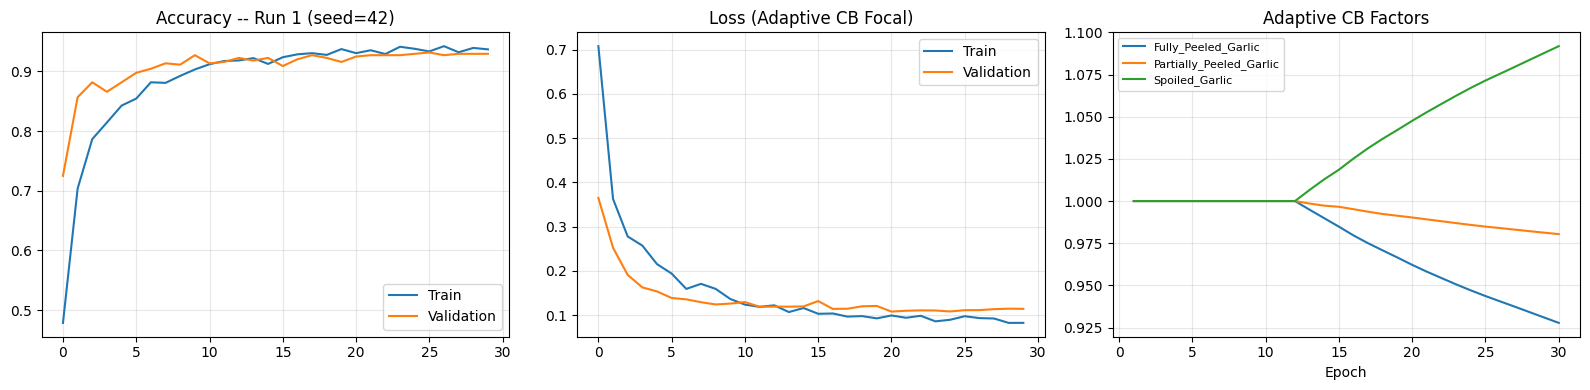


  Single Acc=0.9054  Single AUC(macro)=0.9836
  TTA    Acc=0.9077  P=0.9086  R=0.9077  F1=0.9073  AUC(macro)=0.9847

 RUN 2/3  --  seed=123
 Strategy : EfficientNetB4 + Enhanced MS-FSDA + Adaptive CB Focal + TTA  |  LR=2e-05  |  Aug=True  |  TTA=5
 Checkpoint monitor: val_accuracy (max)
  Augmentation: ON  |  train=2060  val=440  test=444
  Samples/class: {'Fully_Peeled_Garlic': 1050, 'Partially_Peeled_Garlic': 306, 'Spoiled_Garlic': 704}
  Multi-scale backbone outputs:
    Local   : block5f_add -> (None, 24, 24, 160)
    Semantic: final output -> (None, 12, 12, 1792)
  [EfficientNetB4 + Enhanced MS-FSDA + Adaptive CB Focal + TTA] 258/475 base layers trainable (BN always frozen)
  Static CB weights: {0: np.float32(0.6313), 1: np.float32(1.5566), 2: np.float32(0.812)}
  Model params: 19,068,204
Epoch 1/30


KeyboardInterrupt: 

In [5]:
# ========== 7. MULTI-RUN TRAINING ========== #

for run_idx, seed in enumerate(RANDOM_SEEDS[:N_RUNS]):
    print("\n" + "="*70)
    print(f" RUN {run_idx+1}/{N_RUNS}  --  seed={seed}")
    print(f" Strategy : {STRATEGY_LABEL}  |  LR={LR}  |  Aug={USE_AUG}  |  TTA={TTA_STEPS}")
    print(f" Checkpoint monitor: {BEST_MODEL_MONITOR} ({BEST_MODEL_MODE})")
    print("="*70)

    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

    RESULT_DIR = os.path.join(BASE_RESULT_DIR, f"run_{run_idx+1}_seed_{seed}")
    os.makedirs(RESULT_DIR, exist_ok=True)

    # -- Build datasets -----------------------------------------------------
    train_ds, val_ds, test_ds, meta = create_tf_datasets(
        DATA_DIR, INPUT_SHAPE, BATCH_SIZE, seed=seed, use_aug=USE_AUG)
    steps_per_epoch = max(meta.n_train // BATCH_SIZE, 1)

    # -- Build Enhanced FSDA model -----------------------------------------
    model, vis_model, loss_fn = build_fsda_model(
        INPUT_SHAPE, meta.num_classes, steps_per_epoch, meta.samples_per_class)
    print(f"  Model params: {model.count_params():,}")

    adaptive_cb = TwoPhaseAdaptiveCallback(
        loss_fn=loss_fn,
        val_ds=val_ds,
        num_classes=meta.num_classes,
        class_names=meta.class_names,
        phase1_epochs=PHASE1_EPOCHS,
        tau=ADAPTIVE_TAU,
        min_recall_gap=MIN_RECALL_GAP,
        factor_min=ADAPTIVE_FACTOR_MIN,
        factor_max=ADAPTIVE_FACTOR_MAX,
        recall_ema=ADAPTIVE_RECALL_EMA,
    )

    callbacks = [
        EarlyStopping(monitor=BEST_MODEL_MONITOR, mode=BEST_MODEL_MODE,
                      patience=PATIENCE, restore_best_weights=True, verbose=1),
        CSVLogger(os.path.join(RESULT_DIR, 'training_log.csv'), append=False),
        adaptive_cb,
        ModelCheckpoint(os.path.join(RESULT_DIR, 'best_model.keras'),
                        save_best_only=True, monitor=BEST_MODEL_MONITOR,
                        mode=BEST_MODEL_MODE, verbose=1),
        ModelCheckpoint(os.path.join(RESULT_DIR, 'best_val_loss_model.keras'),
                        save_best_only=True, monitor='val_loss',
                        mode='min', verbose=0),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
    )

    # Save adaptive weight evolution.
    adaptive_history_df = pd.DataFrame([
        {
            'epoch': h['epoch'],
            'phase': h['phase'],
            **{f'recall_{cn}': h['per_class_recall'][i] for i, cn in enumerate(meta.class_names)},
            **{f'ema_recall_{cn}': h['smoothed_recall'][i] for i, cn in enumerate(meta.class_names)},
            **{f'factor_{cn}': h['adaptive_factor'][i] for i, cn in enumerate(meta.class_names)},
        }
        for h in adaptive_cb.history
    ])
    adaptive_history_df.to_csv(os.path.join(RESULT_DIR, 'adaptive_weight_history.csv'), index=False)

    # -- Learning curves ----------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'Accuracy -- Run {run_idx+1} (seed={seed})')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title('Loss (Adaptive CB Focal)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    if len(adaptive_cb.history) > 0:
        epochs_seen = [h['epoch'] for h in adaptive_cb.history]
        for ci, cn in enumerate(meta.class_names):
            factors = [h['adaptive_factor'][ci] for h in adaptive_cb.history]
            axes[2].plot(epochs_seen, factors, label=cn)
    axes[2].set_title('Adaptive CB Factors')
    axes[2].set_xlabel('Epoch')
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'learning_curve.png'), dpi=300)
    plt.show()

    # -- Evaluate on test set ----------------------------------------------
    best_model = load_model(
        os.path.join(RESULT_DIR, 'best_model.keras'),
        custom_objects=CUSTOM_OBJECTS,
        compile=False,
    )

    pred_probs_single = best_model.predict(test_ds, verbose=0)
    y_pred_single = np.argmax(pred_probs_single, axis=1)
    single_acc = np.mean(y_pred_single == meta.test_classes)
    single_auc = compute_multiclass_auc(meta.test_classes, pred_probs_single, meta.class_names)

    if TTA_STEPS and TTA_STEPS > 1:
        pred_probs = tta_predict(best_model, test_ds, tta_steps=TTA_STEPS)
    else:
        pred_probs = pred_probs_single

    y_pred_run = np.argmax(pred_probs, axis=1)
    y_true_run = meta.test_classes
    class_names = meta.class_names

    report = classification_report(
        y_true_run, y_pred_run,
        target_names=class_names, output_dict=True, digits=4)
    test_acc = np.mean(y_pred_run == y_true_run)
    auc_metrics = compute_multiclass_auc(y_true_run, pred_probs, class_names)

    with open(os.path.join(RESULT_DIR, 'classification_report.txt'), 'w') as f:
        f.write(classification_report(
            y_true_run, y_pred_run, target_names=class_names, digits=4))

    with open(os.path.join(RESULT_DIR, 'auc_report.txt'), 'w') as f:
        f.write('Multiclass AUC (one-vs-rest)\n')
        f.write(f"Macro AUC    : {auc_metrics['auc_macro']:.4f}\n")
        f.write(f"Weighted AUC : {auc_metrics['auc_weighted']:.4f}\n")
        f.write(f"Micro AUC    : {auc_metrics['auc_micro']:.4f}\n")
        f.write(f"\nSingle-view Macro AUC: {single_auc['auc_macro']:.4f}\n")
        f.write(f"TTA steps            : {TTA_STEPS}\n")
        f.write('\nPer-class AUC:\n')
        for class_name, class_auc in auc_metrics['per_class_auc'].items():
            f.write(f'  {class_name}: {class_auc:.4f}\n')

    # Confusion matrix
    cm = confusion_matrix(y_true_run, y_pred_run)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix -- Run {run_idx+1} (seed={seed})')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'confusion_matrix.png'), dpi=300)
    plt.close()

    # ROC curves (one-vs-rest)
    fig, ax = plt.subplots(figsize=(7, 6))
    for class_name, (fpr, tpr) in auc_metrics['roc_curves'].items():
        ax.plot(fpr, tpr, linewidth=2,
                label=f"{class_name} (AUC={auc_metrics['per_class_auc'][class_name]:.4f})")
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f"ROC Curves OvR -- Run {run_idx+1} (Macro AUC={auc_metrics['auc_macro']:.4f})")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'roc_curves_ovr.png'), dpi=300)
    plt.close()

    all_runs_results.append({
        'run':               run_idx + 1,
        'seed':              seed,
        'accuracy':          test_acc,
        'accuracy_single':   single_acc,
        'precision':         report['weighted avg']['precision'],
        'recall':            report['weighted avg']['recall'],
        'f1_score':          report['weighted avg']['f1-score'],
        'auc_macro':         auc_metrics['auc_macro'],
        'auc_weighted':      auc_metrics['auc_weighted'],
        'auc_micro':         auc_metrics['auc_micro'],
        'auc_macro_single':  single_auc['auc_macro'],
        'per_class_auc':     auc_metrics['per_class_auc'],
        'roc_curves':        auc_metrics['roc_curves'],
        'per_class_metrics': {c: {'precision': report[c]['precision'],
                                   'recall':    report[c]['recall'],
                                   'f1-score':  report[c]['f1-score']}
                               for c in class_names},
        'adaptive_history':  adaptive_cb.history,
        'result_dir':        RESULT_DIR,
        'history':           history.history,
        'y_true':            y_true_run,
        'y_pred':            y_pred_run,
        'pred_probs':        pred_probs,
        'pred_probs_single': pred_probs_single,
        'class_names':       class_names,
        'test_filenames':    meta.test_filenames,
        'n_train':           meta.n_train,
        'n_val':             meta.n_val,
        'n_test':            meta.n_test,
        'best_model_path':   os.path.join(RESULT_DIR, 'best_model.keras'),
    })

    print(f"\n  Single Acc={single_acc:.4f}  Single AUC(macro)={single_auc['auc_macro']:.4f}")
    print(f"  TTA    Acc={test_acc:.4f}  "
          f"P={report['weighted avg']['precision']:.4f}  "
          f"R={report['weighted avg']['recall']:.4f}  "
          f"F1={report['weighted avg']['f1-score']:.4f}  "
          f"AUC(macro)={auc_metrics['auc_macro']:.4f}")

    tf.keras.backend.clear_session()

# -- Save per-run summary CSV ----------------------------------------------
summary_path = os.path.join(BASE_RESULT_DIR, 'strategy_summary.csv')
with open(summary_path, 'w', newline='') as csvf:
    fieldnames = ['strategy_key', 'strategy_label', 'unfreeze_blocks', 'lr', 'min_lr',
                  'weight_decay', 'use_aug', 'fsda_reduction', 'fsda_spatial_ks',
                  'adaptive_tau', 'phase1_epochs', 'adaptive_factor_min',
                  'adaptive_factor_max', 'adaptive_recall_ema',
                  'best_model_monitor', 'best_model_mode', 'tta_steps',
                  'run', 'seed', 'accuracy_single', 'accuracy', 'precision', 'recall', 'f1_score',
                  'auc_macro_single', 'auc_macro', 'auc_weighted', 'auc_micro']
    writer = csv.DictWriter(csvf, fieldnames=fieldnames)
    writer.writeheader()
    for r in all_runs_results:
        writer.writerow({
            'strategy_key':       STRATEGY_KEY,
            'strategy_label':     STRATEGY_LABEL,
            'unfreeze_blocks':    str(UNFREEZE_BLOCKS),
            'lr':                 LR,
            'min_lr':             MIN_LR,
            'weight_decay':       WEIGHT_DECAY,
            'use_aug':            USE_AUG,
            'fsda_reduction':     FSDA_REDUCTION,
            'fsda_spatial_ks':    FSDA_SPATIAL_KS,
            'adaptive_tau':       ADAPTIVE_TAU,
            'phase1_epochs':      PHASE1_EPOCHS,
            'adaptive_factor_min': ADAPTIVE_FACTOR_MIN,
            'adaptive_factor_max': ADAPTIVE_FACTOR_MAX,
            'adaptive_recall_ema': ADAPTIVE_RECALL_EMA,
            'best_model_monitor': BEST_MODEL_MONITOR,
            'best_model_mode':    BEST_MODEL_MODE,
            'tta_steps':          TTA_STEPS,
            'run':                r['run'],
            'seed':               r['seed'],
            'accuracy_single':    r['accuracy_single'],
            'accuracy':           r['accuracy'],
            'precision':          r['precision'],
            'recall':             r['recall'],
            'f1_score':           r['f1_score'],
            'auc_macro_single':   r['auc_macro_single'],
            'auc_macro':          r['auc_macro'],
            'auc_weighted':       r['auc_weighted'],
            'auc_micro':          r['auc_micro'],
        })

print("\n" + "="*70)
print(f" ALL {N_RUNS} RUN(S) COMPLETED -- {STRATEGY_LABEL}")
print(f" Saved summary -> {summary_path}")
print("="*70)


---
## Section 2 — Results Aggregation & Scientific Reports

In [ ]:
# ========== 8. AGGREGATE RESULTS ========== #

accuracies = [r['accuracy']  for r in all_runs_results]
accuracies_single = [r['accuracy_single'] for r in all_runs_results]
precisions = [r['precision'] for r in all_runs_results]
recalls    = [r['recall']    for r in all_runs_results]
f1_scores  = [r['f1_score']  for r in all_runs_results]
auc_macros = [r['auc_macro'] for r in all_runs_results]
auc_macros_single = [r['auc_macro_single'] for r in all_runs_results]
auc_weights = [r['auc_weighted'] for r in all_runs_results]
auc_micros = [r['auc_micro'] for r in all_runs_results]

overall_stats = {
    'Accuracy (single)': {'mean': np.mean(accuracies_single), 'std': np.std(accuracies_single), 'values': accuracies_single},
    'Accuracy (TTA)': {'mean': np.mean(accuracies), 'std': np.std(accuracies), 'values': accuracies},
    'Precision': {'mean': np.mean(precisions), 'std': np.std(precisions), 'values': precisions},
    'Recall':    {'mean': np.mean(recalls),    'std': np.std(recalls),    'values': recalls},
    'F1-Score':  {'mean': np.mean(f1_scores),  'std': np.std(f1_scores),  'values': f1_scores},
    'AUC Macro (single)': {'mean': np.nanmean(auc_macros_single), 'std': np.nanstd(auc_macros_single), 'values': auc_macros_single},
    'AUC Macro (TTA)': {'mean': np.nanmean(auc_macros), 'std': np.nanstd(auc_macros), 'values': auc_macros},
    'AUC Weight': {'mean': np.nanmean(auc_weights), 'std': np.nanstd(auc_weights), 'values': auc_weights},
    'AUC Micro': {'mean': np.nanmean(auc_micros), 'std': np.nanstd(auc_micros), 'values': auc_micros},
}

print("OVERALL METRICS ACROSS ALL RUNS:")
print("-" * 60)
for metric_name, stats in overall_stats.items():
    print(f"{metric_name:18s}: {stats['mean']:.4f} +/- {stats['std']:.4f}")
    print(f"                    Individual: {[f'{v:.4f}' for v in stats['values']]}")
print("-" * 60)

class_names = list(all_runs_results[0]['per_class_metrics'].keys())
per_class_stats = {}
for cn in class_names:
    per_class_stats[cn] = {}
    for metric in ['precision', 'recall', 'f1-score']:
        values = [r['per_class_metrics'][cn][metric] for r in all_runs_results]
        per_class_stats[cn][metric] = {
            'mean': np.mean(values), 'std': np.std(values), 'values': values
        }
    auc_values = [r['per_class_auc'][cn] for r in all_runs_results]
    per_class_stats[cn]['auc'] = {
        'mean': np.nanmean(auc_values), 'std': np.nanstd(auc_values), 'values': auc_values
    }

# -- Summary table ----------------------------------------------------------
metric_order = ['Accuracy (single)', 'Accuracy (TTA)', 'Precision', 'Recall', 'F1-Score',
                'AUC Macro (single)', 'AUC Macro (TTA)', 'AUC Weight', 'AUC Micro']
overall_df = pd.DataFrame({
    'Metric': metric_order,
    'Mean':   [overall_stats[m]['mean'] for m in metric_order],
    'Std':    [overall_stats[m]['std']  for m in metric_order],
})
overall_df['Mean +/- Std'] = overall_df.apply(
    lambda row: f"{row['Mean']:.4f} +/- {row['Std']:.4f}", axis=1)
for i in range(len(all_runs_results)):
    overall_df[f'Run {i+1}'] = [
        accuracies_single[i], accuracies[i], precisions[i], recalls[i], f1_scores[i],
        auc_macros_single[i], auc_macros[i], auc_weights[i], auc_micros[i]]

print("\nSUMMARY TABLE")
print("=" * 70)
run_cols = [f'Run {i+1}' for i in range(len(all_runs_results))]
print(overall_df[['Metric', 'Mean +/- Std'] + run_cols].to_string(index=False))
print("=" * 70)
overall_df.to_csv(os.path.join(BASE_RESULT_DIR, 'overall_metrics_summary.csv'), index=False)
print(f"\nSaved -> {BASE_RESULT_DIR}/overall_metrics_summary.csv")


In [ ]:
# ========== 9. PER-CLASS METRICS BAR CHART ========== #

metrics_to_plot = ['precision', 'recall', 'f1-score', 'auc']
x = np.arange(len(class_names))
bar_w = 0.20
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(max(10, len(class_names) * 1.5), 5))
for i, metric in enumerate(metrics_to_plot):
    means = [per_class_stats[cn][metric]['mean'] for cn in class_names]
    stds  = [per_class_stats[cn][metric]['std']  for cn in class_names]
    ax.bar(x + i * bar_w, means, bar_w, yerr=stds, label=metric.capitalize(),
           color=colors[i], alpha=0.85, capsize=4, edgecolor='white')

ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title(f'Per-Class Metrics -- {STRATEGY_LABEL}\n(Mean +/- Std over {N_RUNS} runs)',
             fontweight='bold')
ax.set_xticks(x + bar_w)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'per_class_metrics.png'), dpi=300)
plt.show()

In [ ]:
# ========== 10. AGGREGATE CONFUSION MATRIX ========== #

agg_cm = np.zeros((len(class_names), len(class_names)), dtype=int)
for r in all_runs_results:
    agg_cm += confusion_matrix(r['y_true'], r['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(agg_cm, annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Aggregate Confusion Matrix (raw counts, {N_RUNS} runs)')

# Normalised
cm_norm = agg_cm.astype(float) / agg_cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=axes[1], vmin=0, vmax=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Aggregate Confusion Matrix (normalised)')

plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'agg_confusion_matrix.png'), dpi=300)
plt.show()

In [ ]:
# ========== 11. ROC CURVES (best run) ========== #

best_run = max(all_runs_results, key=lambda r: r['accuracy'])
y_true_b = best_run['y_true']
y_prob_b = best_run['pred_probs']
nc       = len(class_names)

y_bin = label_binarize(y_true_b, classes=list(range(nc)))
fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), y_prob_b.ravel())

fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.get_cmap('tab10', nc)
for i, cn in enumerate(class_names):
    fpr_i, tpr_i = best_run['roc_curves'][cn]
    ax.plot(fpr_i, tpr_i, color=cmap(i),
            label=f"{cn} (AUC={best_run['per_class_auc'][cn]:.3f})", linewidth=1.5)
ax.plot(fpr_micro, tpr_micro, 'k--',
        label=f"Micro avg (AUC={best_run['auc_micro']:.3f})", linewidth=2)
ax.text(0.60, 0.08, f"Macro AUC={best_run['auc_macro']:.3f}\nWeighted AUC={best_run['auc_weighted']:.3f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
ax.plot([0, 1], [0, 1], 'gray', linestyle=':', linewidth=1)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title(f'ROC Curves -- {STRATEGY_LABEL}\n(Best run: seed={best_run["seed"]})',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'roc_curves.png'), dpi=300)
plt.show()
print(f"Macro-average AUC: {best_run['auc_macro']:.4f}")
print(f"Weighted-average AUC: {best_run['auc_weighted']:.4f}")
print(f"Micro-average AUC: {best_run['auc_micro']:.4f}")

---
## Section 3 — FSDA Attention Map Visualization

**This section is unique to the FSDA architecture.**  
The spatial attention map from `FSDABlock` shows WHERE the model focuses within each image — directly interpretable as "disease localization" without needing Grad-CAM.

In [ ]:
# ========== 12. FSDA SPATIAL ATTENTION MAP VISUALIZATION ========== #
# Shows the 12x12 spatial attention map overlaid on the original image.
# Bright regions = where FSDA told the model to focus.
# NOTE: No retraining needed — vis_model is rebuilt from saved weights.

best_run   = max(all_runs_results, key=lambda r: r['accuracy'])
best_model = load_model(
    best_run['best_model_path'], custom_objects=CUSTOM_OBJECTS, compile=False)

# ── Rebuild vis_model that also outputs the spatial attention map ──────────
# best_model only outputs 'predictions'. To get sp_attn we re-call the FSDA
# layer on its own input tensor (already in the graph), which shares weights.
fsda_layer = best_model.get_layer('fsda')
fsda_in    = fsda_layer.input              # KerasTensor fed into FSDABlock
_, sp_attn_map, _ = fsda_layer(fsda_in)    # re-call -> (fused, sp_attn, branch_gate)

vis_model = Model(
    inputs  = best_model.input,
    outputs = [best_model.output, sp_attn_map],
    name    = 'vis_model',
)

h, w = INPUT_SHAPE[:2]

# Sample 2 images per class from the test set
test_dir           = os.path.join(DATA_DIR, 'test')
class_names_sorted = sorted(os.listdir(test_dir))
samples_per_class  = 2

sample_imgs, sample_paths, sample_labels = [], [], []
for cn in class_names_sorted:
    cls_dir = os.path.join(test_dir, cn)
    imgs = sorted([
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])[:samples_per_class]
    for fname in imgs:
        fpath = os.path.join(cls_dir, fname)
        orig  = tf.image.decode_image(tf.io.read_file(fpath), channels=3, expand_animations=False)
        orig  = tf.image.resize(orig, [h, w]).numpy().astype(np.uint8)
        sample_imgs.append(orig)
        sample_paths.append(fpath)
        sample_labels.append(cn)

# Batch inference
preprocessed = np.stack([
    efficientnet_preprocess(
        tf.cast(tf.image.resize(
            tf.image.decode_image(tf.io.read_file(p), channels=3, expand_animations=False),
            [h, w]), tf.float32)).numpy()
    for p in sample_paths
])
preds_vis, attn_maps = vis_model(preprocessed, training=False)
pred_classes = [class_names_sorted[i] for i in np.argmax(preds_vis.numpy(), axis=1)]
attn_maps    = attn_maps.numpy()   # (N, 12, 12, 1) float32

# Plot: original | attention overlay
n_samples = len(sample_imgs)
fig, axes = plt.subplots(n_samples, 2, figsize=(6, n_samples * 2.8))
fig.suptitle(f'FSDA Spatial Attention Maps -- {STRATEGY_LABEL}\n'
             f'(best run, seed={best_run["seed"]})',
             fontsize=11, fontweight='bold')

for idx in range(n_samples):
    orig    = sample_imgs[idx]
    attn    = attn_maps[idx, :, :, 0]                    # (12, 12)
    attn_up = tf.image.resize(
        attn[..., np.newaxis], [h, w]).numpy()[:, :, 0]  # upsample to H x W

    attn_n  = (attn_up - attn_up.min()) / (attn_up.max() - attn_up.min() + 1e-8)
    heatmap = (cm_lib.jet(attn_n)[:, :, :3] * 255).astype(np.uint8)
    overlay = (0.55 * orig + 0.45 * heatmap).astype(np.uint8)

    correct = sample_labels[idx] == pred_classes[idx]
    color   = 'green' if correct else 'red'
    conf    = float(np.max(preds_vis.numpy()[idx]))

    axes[idx, 0].imshow(orig)
    axes[idx, 0].set_title(f'True: {sample_labels[idx]}', fontsize=8)
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(overlay)
    axes[idx, 1].set_title(
        f'Pred: {pred_classes[idx]} ({conf:.2f})', fontsize=8, color=color)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'fsda_attention_maps.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved FSDA attention maps -> {BASE_RESULT_DIR}/fsda_attention_maps.png")

In [ ]:
# ========== 13. FREQUENCY SPECTRUM VISUALIZATION ========== #
# Shows the FFT magnitude spectrum for sample images per class.
# Motivation: confirms that disease classes have distinct frequency signatures.

fig, axes = plt.subplots(
    len(class_names_sorted), 3,
    figsize=(10, len(class_names_sorted) * 2.5))
fig.suptitle('Frequency Spectrum per Class\n'
             '(FSDA motivation: disease patterns create distinct frequency signatures)',
             fontsize=10, fontweight='bold')

for ci, cn in enumerate(class_names_sorted):
    cls_dir  = os.path.join(test_dir, cn)
    fpath    = os.path.join(cls_dir, sorted(os.listdir(cls_dir))[0])
    orig_rgb = tf.image.resize(
        tf.image.decode_image(tf.io.read_file(fpath), channels=3, expand_animations=False),
        [h, w]).numpy().astype(np.uint8)

    # Convert to grayscale for FFT display
    gray   = np.mean(orig_rgb, axis=-1)          # (H, W)
    f      = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    mag    = np.log1p(np.abs(fshift))             # log-magnitude

    # Radial average (1D frequency profile)
    cy, cx = np.array(mag.shape) // 2
    Y, X   = np.ogrid[:mag.shape[0], :mag.shape[1]]
    R      = np.sqrt((X - cx)**2 + (Y - cy)**2).astype(int)
    r_max  = min(cy, cx)
    radial = np.array([mag[R == r].mean() if (R == r).any() else 0
                        for r in range(r_max)])

    axes[ci, 0].imshow(orig_rgb)
    axes[ci, 0].set_title(cn, fontsize=8, fontweight='bold')
    axes[ci, 0].axis('off')

    axes[ci, 1].imshow(mag, cmap='inferno')
    axes[ci, 1].set_title('FFT log-magnitude', fontsize=7)
    axes[ci, 1].axis('off')

    axes[ci, 2].plot(radial, linewidth=1.2, color='steelblue')
    axes[ci, 2].set_title('Radial frequency profile', fontsize=7)
    axes[ci, 2].set_xlabel('Frequency (cycles/image)', fontsize=6)
    axes[ci, 2].set_ylabel('Avg magnitude', fontsize=6)
    axes[ci, 2].grid(alpha=0.3)
    axes[ci, 2].tick_params(labelsize=6)

plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'frequency_spectra.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved frequency spectra -> {BASE_RESULT_DIR}/frequency_spectra.png")

In [ ]:
# ========== 14. t-SNE FEATURE VISUALIZATION ========== #

import gc

# Clear GPU memory BEFORE loading the model (not after)
gc.collect()
tf.keras.backend.clear_session()

best_run   = max(all_runs_results, key=lambda r: r['accuracy'])
best_model = load_model(
    best_run['best_model_path'], custom_objects=CUSTOM_OBJECTS, compile=False)

# Feature extractor: output of gated multi-scale FSDA fusion.
fusion_output = best_model.get_layer('scale_fusion').output[0]
gap_model = Model(
    inputs  = best_model.input,
    outputs = fusion_output,
)

# Extract test features with smaller batch size to avoid OOM
_, _, test_ds_tsne, meta_tsne = create_tf_datasets(
    DATA_DIR, INPUT_SHAPE, 8, seed=best_run['seed'], use_aug=False)

feats_list, labels_list = [], []
for batch_x, batch_y in test_ds_tsne:
    try:
        feats_batch = gap_model(batch_x, training=False).numpy()
        feats_list.append(feats_batch)
        labels_list.append(np.argmax(batch_y.numpy(), axis=1))
    except tf.errors.ResourceExhaustedError:
        # If still OOM, process in even smaller chunks
        sub_batch_size = 2
        for i in range(0, batch_x.shape[0], sub_batch_size):
            sub_x = batch_x[i:i+sub_batch_size]
            sub_y = batch_y[i:i+sub_batch_size]
            feats_batch = gap_model(sub_x, training=False).numpy()
            feats_list.append(feats_batch)
            labels_list.append(np.argmax(sub_y.numpy(), axis=1))

feats  = np.concatenate(feats_list)
labels = np.concatenate(labels_list)

# Free GPU memory after feature extraction (t-SNE runs on CPU)
del gap_model, best_model
gc.collect()

# t-SNE
print(f"Running t-SNE on {feats.shape[0]} samples x {feats.shape[1]} dims...")
tsne    = TSNE(n_components=2, perplexity=30, random_state=best_run['seed'],
               n_iter=1000, verbose=0)
coords  = tsne.fit_transform(feats)

fig, ax = plt.subplots(figsize=(9, 7))
cmap    = plt.cm.get_cmap('tab10', len(class_names))
for ci, cn in enumerate(class_names):
    mask = labels == ci
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=cmap(ci), label=cn, alpha=0.7, s=20, edgecolors='none')
ax.set_title(f't-SNE of FSDA-attended GAP features\n'
             f'{STRATEGY_LABEL} (seed={best_run["seed"]})',
             fontweight='bold')
ax.legend(loc='upper right', fontsize=8, markerscale=2)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'tsne.png'), dpi=300)
plt.show()
print(f"Saved t-SNE visualization -> {BASE_RESULT_DIR}/tsne.png")

In [ ]:
# ========== 15. GRAD-CAM++ (on EfficientNetB4 top conv features) ========== #

import gc

def gradcam_pp(model, img_array, layer_name, class_idx=None):
    """
    Grad-CAM++ heatmap. Works with mixed-precision models (float16 layers).

    Key: watch conv_out_orig (float16) explicitly so the tape records
    loss → conv_out_orig gradients. Cast to float32 AFTER gradient computation.
    """
    grad_model = Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        tape.watch(img_array)
        conv_out_orig, preds = grad_model(img_array, training=False)
        # Explicitly watch the layer output (may be float16) so the tape
        # can compute d(loss)/d(conv_out_orig) even in mixed-precision.
        tape.watch(conv_out_orig)
        preds_f32 = tf.cast(preds, tf.float32)
        if class_idx is None:
            class_idx = tf.argmax(preds_f32[0])
        loss = preds_f32[:, class_idx]

    # Gradient w.r.t. the original (possibly float16) layer output
    grads    = tape.gradient(loss, conv_out_orig)
    # Cast both to float32 for all subsequent arithmetic
    grads    = tf.cast(grads,         tf.float32)
    conv_out = tf.cast(conv_out_orig, tf.float32)

    grads_sq  = grads ** 2
    grads_cu  = grads ** 3
    alpha_num = grads_sq
    alpha_den = 2 * grads_sq + conv_out * grads_cu
    alpha_den = tf.where(alpha_den == 0, tf.ones_like(alpha_den), alpha_den)
    alpha     = alpha_num / alpha_den
    relu_grad = tf.nn.relu(loss * grads)
    weights   = tf.reduce_mean(alpha * relu_grad, axis=(1, 2))[0]
    cam       = tf.reduce_sum(conv_out[0] * weights, axis=-1).numpy()
    cam       = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam


# Clear GPU memory before loading model
gc.collect()
tf.keras.backend.clear_session()

best_run   = max(all_runs_results, key=lambda r: r['accuracy'])
best_model = load_model(
    best_run['best_model_path'], custom_objects=CUSTOM_OBJECTS, compile=False)

# Sub-layers inside FSDABlock are NOT exposed as top-level model layers.
# 'top_activation' is the last EfficientNetB4 feature map before FSDA.
target_layer = 'top_activation'

n_display = min(3, len(sample_imgs))
fig, axes  = plt.subplots(n_display, 3, figsize=(11, n_display * 3.2))
fig.suptitle(f'Grad-CAM++ on EfficientNetB4 top conv features\n{STRATEGY_LABEL}',
             fontsize=10, fontweight='bold')

for idx in range(n_display):
    orig   = sample_imgs[idx]
    p      = sample_paths[idx]
    prep   = efficientnet_preprocess(
        tf.cast(tf.image.resize(
            tf.image.decode_image(tf.io.read_file(p), channels=3, expand_animations=False),
            [h, w]), tf.float32))[np.newaxis]
    prep_t = tf.Variable(tf.cast(prep, tf.float32))

    cam    = gradcam_pp(best_model, prep_t, target_layer)
    cam_up = tf.image.resize(cam[..., np.newaxis], [h, w]).numpy()[:, :, 0]
    hmap   = (cm_lib.jet(cam_up)[:, :, :3] * 255).astype(np.uint8)
    overlay = (0.55 * orig + 0.45 * hmap).astype(np.uint8)

    pred_idx  = np.argmax(best_model(prep_t, training=False).numpy())
    pred_name = class_names[pred_idx]
    correct   = sample_labels[idx] == pred_name

    axes[idx, 0].imshow(orig)
    axes[idx, 0].set_title(f'Original: {sample_labels[idx]}', fontsize=8)
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(cam_up, cmap='jet')
    axes[idx, 1].set_title('Grad-CAM++ heatmap', fontsize=8)
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title(
        f'Pred: {pred_name}', fontsize=8,
        color='green' if correct else 'red')
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'gradcam_pp.png'), dpi=200)
plt.show()

# Free GPU memory for next cell
del best_model
gc.collect()

In [ ]:
# ========== 16. INFERENCE SPEED BENCHMARK ========== #

import gc

# Explicitly delete any lingering model references from previous cells,
# then clear the Keras session to free all GPU memory
for _var in ['best_model', 'gap_model', 'vis_model']:
    if _var in dir():
        del _var
gc.collect()
tf.keras.backend.clear_session()

best_run   = max(all_runs_results, key=lambda r: r['accuracy'])
best_model = load_model(
    best_run['best_model_path'], custom_objects=CUSTOM_OBJECTS, compile=False)

SPEED_BATCH = 4  # Reduced to 4 to avoid OOM on large EfficientNetB4+FSDA
_, _, test_ds_speed, _ = create_tf_datasets(
    DATA_DIR, INPUT_SHAPE, SPEED_BATCH, seed=42, use_aug=False)

# Warm-up (1 batch only)
for batch_x, _ in test_ds_speed.take(1):
    _ = best_model(batch_x, training=False)

# Benchmark
n_batches, total_imgs, total_t = 0, 0, 0.0
for batch_x, _ in test_ds_speed:
    t0 = time.perf_counter()
    _  = best_model(batch_x, training=False)
    total_t   += time.perf_counter() - t0
    total_imgs += batch_x.shape[0]
    n_batches  += 1

ms_per_img   = total_t / total_imgs * 1000
imgs_per_sec = total_imgs / total_t

print("=" * 50)
print("INFERENCE SPEED BENCHMARK")
print(f"  Images tested  : {total_imgs}")
print(f"  Total time     : {total_t:.3f} s")
print(f"  ms / image     : {ms_per_img:.2f} ms")
print(f"  Images / second: {imgs_per_sec:.1f}")
print("=" * 50)

In [ ]:
# ========== 17. MODEL SUMMARY ========== #

import gc

gc.collect()
tf.keras.backend.clear_session()

best_run   = max(all_runs_results, key=lambda r: r['accuracy'])
best_model = load_model(
    best_run['best_model_path'], custom_objects=CUSTOM_OBJECTS, compile=False)

total_params     = best_model.count_params()
trainable_params = sum(tf.size(v).numpy() for v in best_model.trainable_weights)
frozen_params    = total_params - trainable_params

print("=" * 60)
print("MODEL SUMMARY")
print(f"  Architecture : EfficientNetB4 + Enhanced Multi-Scale FSDABlock")
print(f"  Total params : {total_params:,}")
print(f"  Trainable    : {trainable_params:,}")
print(f"  Frozen       : {frozen_params:,}")
print(f"  Input shape  : {INPUT_SHAPE}")
print(f"  FSDA reduction   : {FSDA_REDUCTION}")
print(f"  FSDA spatial_ks  : {FSDA_SPATIAL_KS}")
print("=" * 60)

print("\nFSDA Block layers:")
for layer in best_model.layers:
    if 'fsda' in layer.name:
        print(f"  {layer.name:40s}  params={layer.count_params():,}")

print("\nClassification Head layers:")
for lname in ['gap_local', 'gap_semantic', 'scale_fusion', 'head_bn', 'head_dense', 'head_dropout', 'predictions']:
    try:
        ly = best_model.get_layer(lname)
        # Keras 3 removed .output_shape on layer objects;
        # retrieve it from the model's output tensors instead.
        try:
            out_shape = ly.output.shape
        except AttributeError:
            out_shape = 'N/A'
        print(f"  {ly.name:40s}  output={out_shape}  params={ly.count_params():,}")
    except ValueError:
        pass

In [ ]:
# ========== 18. EXPORT FINAL REPORT ========== #

report_path = os.path.join(BASE_RESULT_DIR, 'final_report.csv')
with open(report_path, 'w', newline='') as f:
    fields = [
        'strategy_key', 'strategy_label', 'unfreeze_blocks',
        'lr', 'min_lr', 'weight_decay', 'use_aug', 'batch_size',
        'fsda_reduction', 'fsda_spatial_ks', 'adaptive_tau', 'phase1_epochs',
        'adaptive_factor_min', 'adaptive_factor_max', 'adaptive_recall_ema',
        'best_model_monitor', 'best_model_mode', 'tta_steps',
        'run', 'seed',
        'accuracy_single', 'accuracy', 'precision', 'recall', 'f1_score',
        'auc_macro_single', 'auc_macro', 'auc_weighted', 'auc_micro',
    ]
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    for r in all_runs_results:
        writer.writerow({
            'strategy_key':       STRATEGY_KEY,
            'strategy_label':     STRATEGY_LABEL,
            'unfreeze_blocks':    str(UNFREEZE_BLOCKS),
            'lr':                 LR,
            'min_lr':             MIN_LR,
            'weight_decay':       WEIGHT_DECAY,
            'use_aug':            USE_AUG,
            'batch_size':         BATCH_SIZE,
            'fsda_reduction':     FSDA_REDUCTION,
            'fsda_spatial_ks':    FSDA_SPATIAL_KS,
            'adaptive_tau':       ADAPTIVE_TAU,
            'phase1_epochs':      PHASE1_EPOCHS,
            'adaptive_factor_min': ADAPTIVE_FACTOR_MIN,
            'adaptive_factor_max': ADAPTIVE_FACTOR_MAX,
            'adaptive_recall_ema': ADAPTIVE_RECALL_EMA,
            'best_model_monitor': BEST_MODEL_MONITOR,
            'best_model_mode':    BEST_MODEL_MODE,
            'tta_steps':          TTA_STEPS,
            'run':                r['run'],
            'seed':               r['seed'],
            'accuracy_single':    f"{r['accuracy_single']:.6f}",
            'accuracy':           f"{r['accuracy']:.6f}",
            'precision':          f"{r['precision']:.6f}",
            'recall':             f"{r['recall']:.6f}",
            'f1_score':           f"{r['f1_score']:.6f}",
            'auc_macro_single':   f"{r['auc_macro_single']:.6f}",
            'auc_macro':          f"{r['auc_macro']:.6f}",
            'auc_weighted':       f"{r['auc_weighted']:.6f}",
            'auc_micro':          f"{r['auc_micro']:.6f}",
        })

acc_mean = np.mean([r['accuracy'] for r in all_runs_results])
acc_std  = np.std( [r['accuracy'] for r in all_runs_results])
f1_mean  = np.mean([r['f1_score'] for r in all_runs_results])
f1_std   = np.std( [r['f1_score'] for r in all_runs_results])
auc_mean = np.nanmean([r['auc_macro'] for r in all_runs_results])
auc_std  = np.nanstd( [r['auc_macro'] for r in all_runs_results])

print("=" * 60)
print("FINAL REPORT")
print(f"  {STRATEGY_LABEL}")
print(f"  Accuracy : {acc_mean:.4f} +/- {acc_std:.4f}")
print(f"  F1-Score : {f1_mean:.4f} +/- {f1_std:.4f}")
print(f"  AUC Macro: {auc_mean:.4f} +/- {auc_std:.4f}")
print(f"  Saved    : {report_path}")
print("=" * 60)

print("\nAll outputs saved to:", BASE_RESULT_DIR)
for fname in sorted(os.listdir(BASE_RESULT_DIR)):
    print(f"  {fname}")


In [ ]:
!zip -r /kaggle/working/efficientnetb4_efsda_adaptivecb_tta.zip /kaggle/working/report_EfficientNetB4/efficientnetb4_efsda_adaptivecb_tta
